In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix

**Data Preprocessing**

- Drop samples with missing values.
- Group genres into categories
- Drop original genre column
- Drop irrelevant features
- Create 80-20 train test split

In [29]:
df=pd.read_csv('../data/dataset.csv', index_col=0)

In [30]:
df = df.dropna(axis=0)
df["explicit"]=df["explicit"].astype(int)

In [35]:
genre_to_category = {
    'edm': 'Electronic/Dance', 'electro': 'Electronic/Dance', 'house': 'Electronic/Dance',
    'trance': 'Electronic/Dance', 'techno': 'Electronic/Dance', 'dubstep': 'Electronic/Dance', 
    'drum-and-bass': 'Electronic/Dance', 'deep-house': 'Electronic/Dance', 'detroit-techno': 'Electronic/Dance', 
    'minimal-techno': 'Electronic/Dance', 'progressive-house': 'Electronic/Dance', 'breakbeat': 'Electronic/Dance',
    'chicago-house': 'Electronic/Dance', 'club': 'Electronic/Dance', 'idm': 'Electronic/Dance',
    'dance': 'Electronic/Dance', 'electronic': 'Electronic/Dance', 'trip-hop': 'Electronic/Dance', 
    
    'alt-rock': 'Rock/Metal', 'rock': 'Rock/Metal', 'punk': 'Rock/Metal', 'punk-rock': 'Rock/Metal',
    'hard-rock': 'Rock/Metal', 'metal': 'Rock/Metal', 'heavy-metal': 'Rock/Metal', 'black-metal': 'Rock/Metal', 
    'death-metal': 'Rock/Metal', 'grunge': 'Rock/Metal', 'garage': 'Rock/Metal', 'goth': 'Rock/Metal',
    'psych-rock': 'Rock/Metal', 'rock-n-roll': 'Rock/Metal', 'rockabilly': 'Rock/Metal', 'hardcore': 'Rock/Metal', 
    'metalcore': 'Rock/Metal', 'industrial': 'Rock/Metal', 'grindcore': 'Rock/Metal',
    
    'indie': 'Indie/Alternative', 'indie-pop': 'Indie/Alternative', 'emo': 'Indie/Alternative', 
    'alternative': 'Indie/Alternative', 'new-age': 'Indie/Alternative', 'psych-rock': 'Indie/Alternative',
    
    'hip-hop': 'Hip-Hop/Rap', 'trap': 'Hip-Hop/Rap', 'rap': 'Hip-Hop/Rap',
    
    'pop': 'Pop', 'electro-pop': 'Pop', 'synth-pop': 'Pop', 'k-pop': 'Pop', 'j-pop': 'Pop', 
    'pop-film': 'Pop', 'power-pop': 'Pop', 'british': 'Pop', 'cantopop': 'Pop', 'mandopop': 'Pop', 'j-idol': 'Pop',
    
    'r-n-b': 'R&B/Soul/Funk', 'soul': 'R&B/Soul/Funk', 'funk': 'R&B/Soul/Funk', 'gospel': 'R&B/Soul/Funk', 
    'blues': 'R&B/Soul/Funk', 'disco': 'R&B/Soul/Funk', 'groove': 'R&B/Soul/Funk',
    
    'jazz': 'Jazz/Blues', 'blues': 'Jazz/Blues', 'bluegrass': 'Jazz/Blues', 'swing': 'Jazz/Blues',
    
    'country': 'Country/Folk', 'folk': 'Country/Folk', 'singer-songwriter': 'Country/Folk', 'honky-tonk': 'Country/Folk',
    
    'classical': 'Classical/Instrumental', 'opera': 'Classical/Instrumental', 'piano': 'Classical/Instrumental', 
    'orchestral': 'Classical/Instrumental', 'instrumental': 'Classical/Instrumental',
    
    'latin': 'Latin/World', 'reggaeton': 'Latin/World', 'salsa': 'Latin/World', 'samba': 'Latin/World', 
    'reggae': 'Latin/World', 'dancehall': 'Latin/World', 'afrobeat': 'Latin/World', 'brazil': 'Latin/World', 
    'latino': 'Latin/World', 'forro': 'Latin/World', 'french': 'Latin/World', 'german': 'Latin/World', 
    'indian': 'Latin/World', 'iranian': 'Latin/World', 'turkish': 'Latin/World', 'swedish': 'Latin/World', 
    'j-dance': 'Latin/World', 'j-rock': 'Latin/World', 'spanish': 'Latin/World', 'malay': 'Latin/World', 
    'tango': 'Latin/World', 'world-music': 'Latin/World', 'pagode': 'Latin/World', 'mpb': 'Latin/World',
    
    'ambient': 'Ambient/Chill', 'chill': 'Ambient/Chill', 'study': 'Ambient/Chill', 'sleep': 'Ambient/Chill', 
    'new-age': 'Ambient/Chill', 'relax': 'Ambient/Chill', 'meditation': 'Ambient/Chill',
    
    'anime': 'Themed/Children', 'children': 'Themed/Children', 'comedy': 'Themed/Children', 
    'disney': 'Themed/Children', 'kids': 'Themed/Children', 'party': 'Themed/Children',
    
    'acoustic': 'Other', 'honky-tonk': 'Other', 'garage': 'Other', 'guitar': 'Other',
    'show-tunes': 'Other', 'songwriter': 'Other', 'happy': 'Other', 'dance-pop': 'Other',
    
    'sad': 'Mood', 'happy': 'Mood', 'romance': 'Mood', 'celebration': 'Mood'
}

df['music_category'] = df['track_genre'].apply(lambda x: genre_to_category.get(x, 'Other'))
df.drop(columns=['track_genre'], inplace=True)

In [38]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,music_category
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,Other
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,Other
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,Other
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,Other
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,Other


In [43]:
features = ['duration_ms', 'explicit', 'danceability', 'energy', 'loudness', 
            'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
target = 'music_category'
X = df[features]
y = df[target]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

**Random Forest Classifier**

- Perform a grid search to optimize hyperparamters.
- Describe performance for each class.
- Plot confusion matrix.

In [ ]:
param_grid = {       
    'max_depth': [5, 10, 20, 30],         
    'min_samples_split': [2, 5, 10],      
    'min_samples_leaf': [1, 2, 4],         
}

rf_model = RandomForestClassifier(n_estimators=100, random_state=0)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='accuracy',        
    cv=5,                      
    verbose=2,                 
    n_jobs=-1                  
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
best_rf_model = RandomForestClassifier(n_estimators=100, random_state=0, class_weight='balanced')
best_rf_model.fit(X_train, y_train)

y_pred = best_rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5003070175438596
Classification Report:
                         precision    recall  f1-score   support

         Ambient/Chill       0.54      0.56      0.55       999
Classical/Instrumental       0.49      0.49      0.49       617
          Country/Folk       0.33      0.34      0.33       581
      Electronic/Dance       0.65      0.70      0.67      3484
           Hip-Hop/Rap       0.26      0.28      0.27       212
     Indie/Alternative       0.35      0.30      0.32      1065
            Jazz/Blues       0.46      0.39      0.42       624
           Latin/World       0.47      0.63      0.54      4751
                  Mood       0.46      0.30      0.36       626
                 Other       0.33      0.25      0.28      2049
                   Pop       0.42      0.33      0.37      2041
         R&B/Soul/Funk       0.35      0.20      0.25      1225
            Rock/Metal       0.58      0.64      0.61      3318
       Themed/Children       0.62      0.46      0

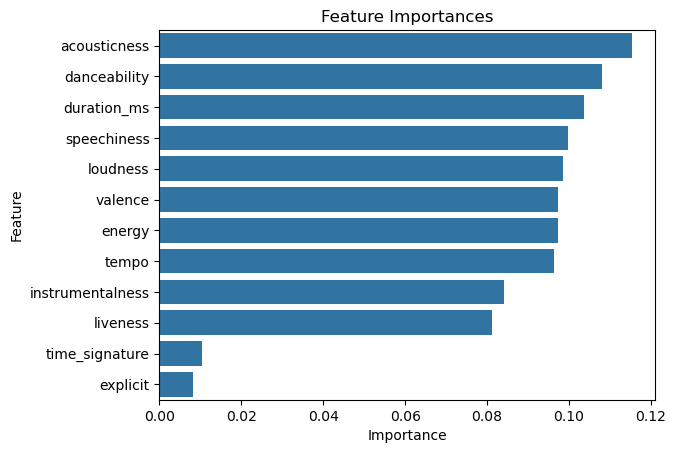

In [64]:
feature_importances = best_rf_model.feature_importances_

sorted_indices = np.argsort(feature_importances)[::-1]  
sorted_features = [features[i] for i in sorted_indices]
sorted_importances = feature_importances[sorted_indices]

sns.barplot(x=sorted_importances, y=sorted_features)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

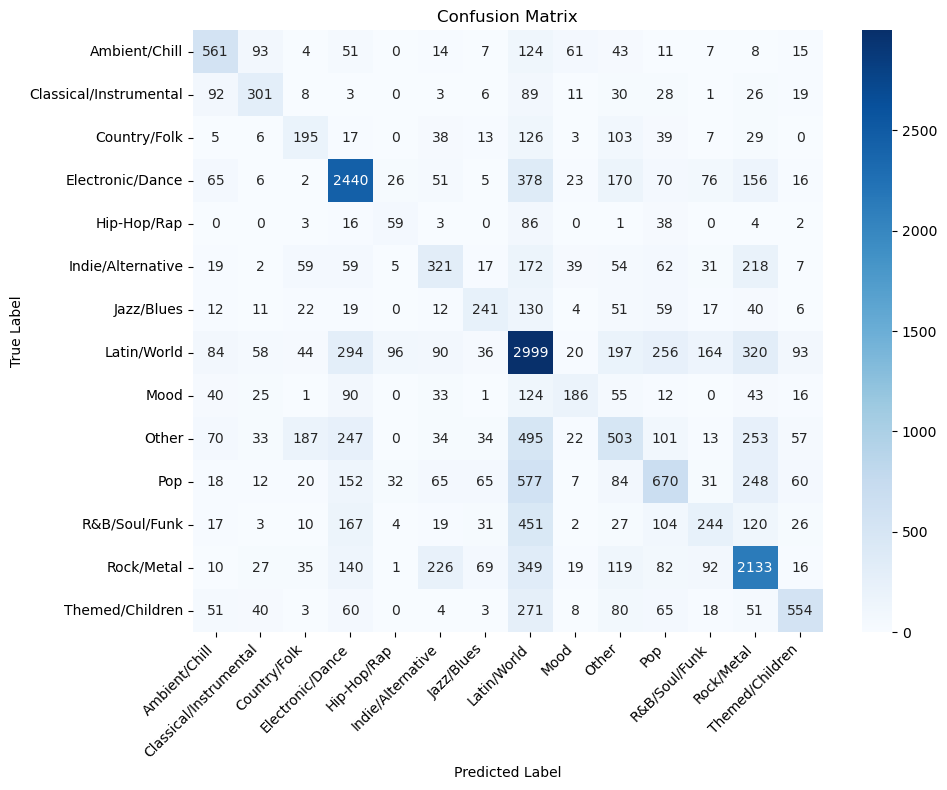

In [61]:
cm = confusion_matrix(y_test, y_pred, labels=best_rf_model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,  
    fmt='d',     
    cmap='Blues', 
    xticklabels=best_rf_model.classes_,
    yticklabels=best_rf_model.classes_ 
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()